In [113]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [114]:
path = r"C:\Users\rajeshkumar.t\Desktop\ML\Account_id.csv"
df= pd.read_csv(path)

In [115]:
print(df.columns)

Index(['Account_id', 'transaction_yr', 'transaction_mth', 'transaction_wk',
       'transaction_dt', 'transaction_status', 'transaction_source',
       'live_response_code', 'payment_instrument', 'bank_code', 'hyp_flag',
       'asp_flag', 'merchant_id', 'merchant_status', 'marketplace_id', 'pg_id',
       'flipkart_emi_flag', 'marketplace_context', 'is_shopsy_order',
       'emi_flag', 'adonc_flag', 'count_of_tx', 'acct_cnt', 'tot_amt',
       'tot_eff_amt_paymnt'],
      dtype='object')


In [116]:
df = df[df['transaction_dt'] != 'transaction_dt']
df1= df[['transaction_dt', 'Account_id', 'tot_amt']].copy()

In [117]:
print(df1)

        transaction_dt                 Account_id  tot_amt
0           01-12-2025   PR2603010006345035524903     5230
1           01-12-2025   PR2603010014279601650601    58650
2           01-12-2025   PR2603010015071167333501       25
3           01-12-2025  PR26030100531918080505205     1090
4           01-12-2025  PR26030101181320871704503    21700
...                ...                        ...      ...
1048570     14-12-2025  PR26030920522022831243105    19078
1048571     14-12-2025  PR26030920522119265206602     4117
1048572     14-12-2025  PR26030920522123135639807     2103
1048573     14-12-2025  PR26030920522311317736504    12819
1048574     14-12-2025  PR26030920523911403724207    23147

[1048575 rows x 3 columns]


In [118]:
print(df1.dtypes)

transaction_dt    object
Account_id        object
tot_amt            int64
dtype: object


In [119]:
df1['transaction_dt'] = df1['transaction_dt'].astype("datetime64[ns]")
snapshot_date = df1['transaction_dt'].max() + pd.Timedelta(days=1)
rfm = df1.groupby('Account_id').agg({
    'transaction_dt': lambda x: (snapshot_date - x.max()).days,
    'Account_id': 'count',
    'tot_amt': 'sum'
}).rename(columns={'transaction_dt': 'Recency', 'Account_id': 'Frequency', 'tot_amt': 'Monetary'}).reset_index()

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=False, duplicates= 'drop') +1
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels= [1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels= [1,2,3,4,5]) 
    

In [120]:
import numpy as np
conditions = [
    (rfm['R_score'].astype(int) >=4) & (rfm['F_score'].astype(int) >=4 ) & (rfm['M_score'].astype(int) >=4),
    (rfm['R_score'].astype(int) >=4) & (rfm['F_score'].astype(int)>=2),
    (rfm['R_score'].astype(int) <=2) & (rfm['F_score'].astype(int) >=4),
    (rfm['R_score'].astype(int) <=2) & (rfm['F_score'].astype(int) <=2)
]
choices = [
    'Champions',
    'New_Customers',
    'At_Risk',
    'Hibernating'
]
rfm['Customer_Segment'] = np.select(conditions, choices, default='Regulars')
#rfm_summary = rfm.groupby('Customer_Segment').size().reset_index(name='count')
print(rfm)

                        Account_id  Recency  Frequency  Monetary  R_score  \
0         PR2603010000059682749503      508          1      3034        5   
1         PR2603010000072684189905      508          1     22455        5   
2         PR2603010000095907554902       32          1    299155        1   
3        PR26030100001125136442602      249          1      1375        2   
4        PR26030100001412497364601      154          1       141        1   
...                            ...      ...        ...       ...      ...   
1045142   PR2603100058367913262504      256          1       660        3   
1045143  PR26031000583718796902605      258          1       430        3   
1045144  PR26031000584117212562008      447          1     10861        5   
1045145  PR26031000584520478002003      598          1     65855        5   
1045146   PR2603100058468564712305      253          1   1918444        3   

        F_score M_score Customer_Segment  
0             1       2         

In [121]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
cols_for_clustering = ['Recency', 'Frequency','Monetary']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(rfm[cols_for_clustering])
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
rfm['K_Cluster'] = kmeans.fit_predict(df_scaled)
comparision = pd.crosstab(rfm['Customer_Segment'], rfm['K_Cluster'])
print("----- Segment Vs Cluster---")
print(comparision)

----- Segment Vs Cluster---
K_Cluster              0       1     2  3   4
Customer_Segment                             
At_Risk           175324       0  2232  0  32
Champions          25643   33492   263  4  40
Hibernating       157119       0     0  0  35
New_Customers     111417  139089   121  0  51
Regulars          340094   59465   635  1  90


In [127]:
import numpy as np
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(rfm_log)
kmeans = KMeans(n_clusters = 5, init= 'k-means++', random_state= 42)
rfm['K_Cluster_New'] = kmeans.fit_predict(df_scaled)
cluster_profile = rfm.groupby('K_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_profile)

              Recency  Frequency      Monetary
K_Cluster                                     
0          230.149671   1.000000  1.628953e+05
1          490.448734   1.000000  1.854674e+05
2          209.126115   2.054445  4.579618e+05
3          403.800000   1.000000  1.950370e+09
4          303.080645   1.000000  2.050674e+08


In [130]:
#The Log Transformation
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler =StandardScaler()
df_scaled_log = scaler.fit_transform(rfm_log)
kmeans = KMeans(n_clusters =5, init= 'k-means++', random_state = 42)
rfm['K_cluster_log'] = kmeans.fit_predict(df_scaled_log)
print(rfm.groupby('K_cluster_log')[['Recency', 'Frequency', 'Monetary']].mean())

                  Recency  Frequency      Monetary
K_cluster_log                                     
0              306.497185   1.000000  1.212530e+03
1               58.119323   1.000000  7.171542e+04
2              301.663998   1.000000  1.293140e+06
3              209.126115   2.054445  4.579618e+05
4              310.609378   1.000000  1.751863e+04


In [132]:
 #Filtering Outliers (The "Clean Slate" Approach)
rfm_filtered = rfm[rfm['Monetary']< 1000000].copy()
scaler = StandardScaler()
df_scaled_f = scaler.fit_transform(rfm_filtered[['Recency', 'Frequency', 'Monetary']])
kmeans=KMeans(n_clusters=5, init='k-means++', random_state=42)
rfm_filtered['K_Cluster_Filtered'] = kmeans.fit_predict(df_scaled_f)
print(rfm_filtered.groupby('K_Cluster_Filtered')[['Recency', 'Frequency', 'Monetary']].mean())

                       Recency  Frequency       Monetary
K_Cluster_Filtered                                      
0                   258.895457   1.000000   22956.582801
1                   208.692283   2.051123   87788.314556
2                   490.907898   1.000000   24819.044953
3                   287.140242   1.000000  517922.462072
4                    90.613487   1.000000   23934.283257


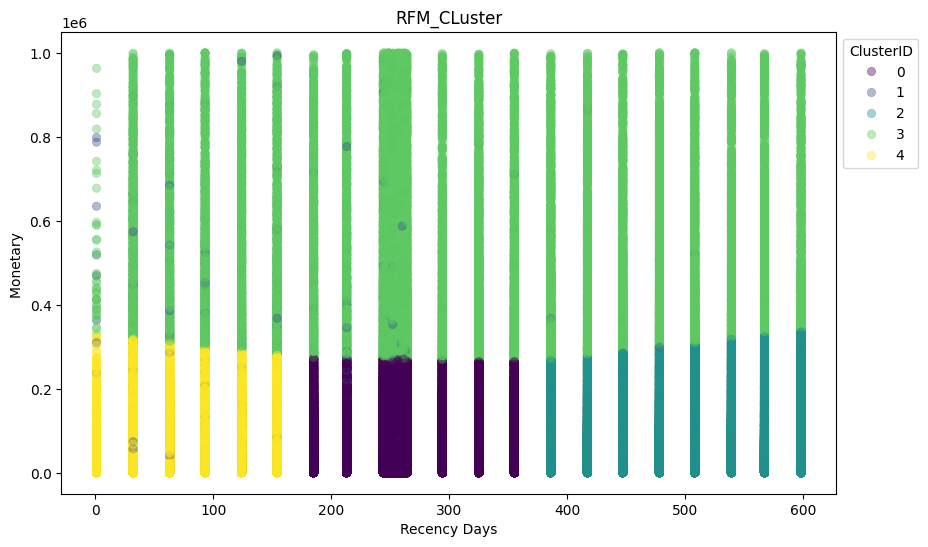

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm_filtered,
    x='Recency',
    y='Monetary',
    hue='K_Cluster_Filtered',
    palette ='viridis',
    alpha=0.4,
    edgecolor=None
   )
plt.title('RFM_CLuster')
plt.xlabel('Recency Days')
plt.ylabel('Monetary ')
plt.legend(bbox_to_anchor=(1,1), title="ClusterID")
plt.show()
           
